# 3. Exploratory Data Analysis (EDA)

**Tasks**:

- Use `seaborn`, `matplotlib`, `plotly`, or `pandas_profiling`
- Plot distributions, correlations, boxplots
- Use pairplots to see clusters visually (especially on 2–3 variables)

**Tips**:

- Visual storytelling helps your GitHub project stand out
- Add markdown cells in your notebook to explain what you're doing

## 3.1. Discovering data distribution

First step, is the loading the cleaned dataset from previous step.

In [2]:
import matplotlib.pyplot as plt # Data visualization
import matplotlib.patheffects as pe
import seaborn as sns # Data visualization
import numpy as np # linear algebra
import pandas as pd # Data processing

import missingno as msno # Analyze data for missing values

In [3]:
raw_data_directory_path = r"D:/Google Drive/Work/Data Analytics and Data Science/Roadpam/project_1-customer-segmentation/data/raw"
processed_data_directory_path = r"D:/Google Drive/Work/Data Analytics and Data Science/Roadpam/project_1-customer-segmentation/data/processed"

In [4]:
df = pd.read_csv(str(processed_data_directory_path) + "/e-commerce-data-cleaned.csv", encoding = 'latin1', index_col = 0)
df

,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2010-12-01,08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2010-12-01,08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,2011-12-09,12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2011-12-09,12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,2011-12-09,12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,2011-12-09,12:50:00,4.15,12680.0,France


The initial phase of the EDA process in this project will involve constructing the plot distribution across variables. Firstly, the following will be analysed based on with the nature of the variable data:
1. *customer_id* - to see the distribution of customers' activity;
2. *stock_code* - to see the distribution of how often the specific good or group of goods is ordered;
3. *invoice_datetime* and *invoice_date* - to analyse the distribution of orders by date and time, and identify the most active periods;
4. *country* - to analyse the the most active clients by country.

Perhaps the following could be tried:
1. Group the *quantity* column into several order size categories, such as “small order,” “medium order,” and “large order.” Then visualize the distribution across these categories.
2. Group the *customer_id* column into several categories based on customer activity, maybe create bins of the number of orders, for example, "< 10" orders, "10-15", and so on. Then visualize the distribution of histogram for this bins.

### 3.1.1. Distribution of *customer_id*
First, start with the *customer_id*, build the distribution chart to understand the pattern of customer activity.

First, determine how many times each customer (*customer_id*) appears in the dataset.

In [5]:
idx = pd.Index(df['customer_id'])
custumer_counts = idx.value_counts()
custumer_counts

customer_id
17841.0    7667
14911.0    5584
14096.0    5095
12748.0    4397
14606.0    2674
           ... 
16881.0       1
12791.0       1
13747.0       1
13703.0       1
13188.0       1
Name: count, Length: 4334, dtype: int64

Once the new data has been received, it becomes possible to examine the summary statistics for the *customer_id* column. This procedure was performed earlier, but now it is being done on the cleaned data.

In [6]:
custumer_counts.describe().T

count    4334.000000
mean       90.232580
std       224.707914
min         1.000000
25%        17.000000
50%        41.000000
75%        98.000000
max      7667.000000
Name: count, dtype: float64

For a more accurate analysis, we also calculate the summary statistics for the column in its original format.

In [18]:
df['customer_id'].describe().T

count    391068.000000
mean      15295.134849
std        1710.345760
min       12346.000000
25%       13969.000000
50%       15158.000000
75%       16794.000000
max       18287.000000
Name: customer_id, dtype: float64

Since the data was imported as numeric values again, the data in this column is being converted to the `object` format.

In [20]:
df['customer_id'] = df['customer_id'].astype('object')
df['customer_id'].describe(include = 'object').T

count     391068.0
unique      4334.0
top        17841.0
freq        7667.0
Name: customer_id, dtype: float64

As is evident, even following the process of data cleansing, the distribution remains skewed, as there are still users with abnormally high activity levels. For instance, customer with ID $17841$ has an activity frequency of $7667$, which differs significantly from both the mean and the median.

To determine whether this is an outlier and if there are other similar customers, as previously mentioned, it is necessary to plot a distribution graph.

In [8]:
customer_mean = np.mean(custumer_counts)
customer_std = np.std(custumer_counts)

print("mean =", customer_mean, "\nstd = ", customer_std)

mean = 90.23257960313798 
std =  224.68198905716062


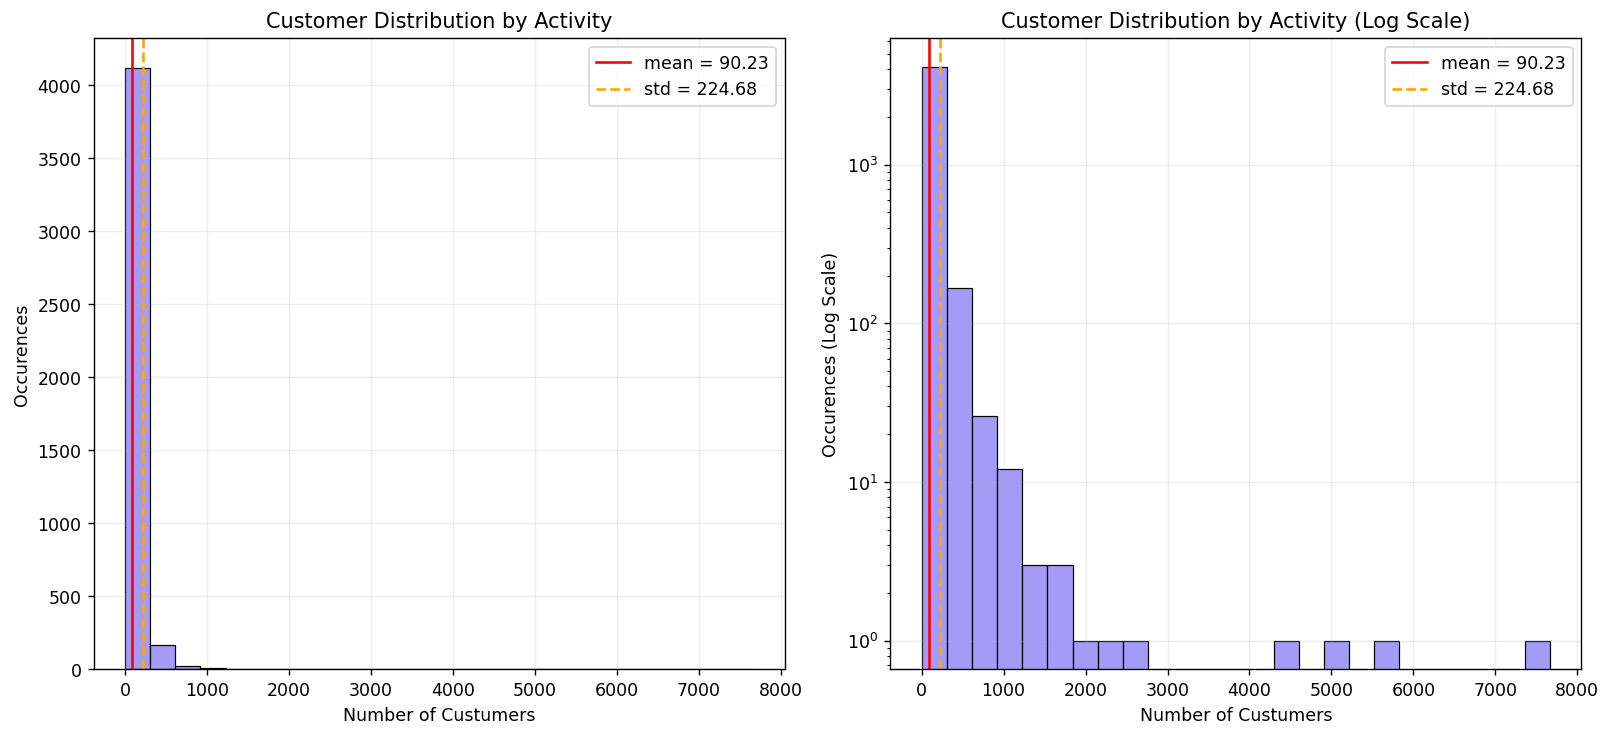

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (13, 6), dpi = 125)

#============ Plot 1 ==========
sns.histplot(custumer_counts, bins = 25, ax = ax1, color = '#8978f5', edgecolor = 'black', linewidth = 0.7)
ax1.axvline(customer_mean, color = 'red', label = f'mean = {customer_mean:.2f}')
ax1.axvline(customer_std, color = 'orange', ls = '--', label = f'std = {customer_std:.2f}')

ax1.set_title('Customer Distribution by Activity')
ax1.set_xlabel('Number of Custumers')
ax1.set_ylabel('Occurences')
ax1.legend()
ax1.grid(alpha = 0.2)

#============ Plot 2 ==========
sns.histplot(custumer_counts, bins = 25, ax = ax2, color = '#8978f5', edgecolor = 'black', linewidth = 0.7)
ax2.axvline(customer_mean, color = 'red', label = f'mean = {customer_mean:.2f}')
ax2.axvline(customer_std, color = 'orange', ls = '--', label = f'std = {customer_std:.2f}')

ax2.set_yscale('log')

ax2.set_title('Customer Distribution by Activity (Log Scale)')
ax2.set_xlabel('Number of Custumers')
ax2.set_ylabel('Occurences (Log Scale)')
ax2.legend()
ax2.grid(alpha = 0.2)


plt.tight_layout() # Prevents labels from overlapping
plt.show()

Calculation of the outliers

To get the lower and upper thresholds the more robust and common way is to use the interquartile range and multiply it by $1.5$. Then this result is subtracted from the $25th$ percentile and added to the $75th$.

In [10]:
customer_25_percentile = np.percentile(custumer_counts, 25)
customer_75_percentile = np.percentile(custumer_counts, 75)

customer_IQR = customer_75_percentile - customer_25_percentile

customer_lower_threshold = customer_25_percentile - (1.5 * customer_IQR)
customer_upper_threshold = customer_75_percentile + (1.5 * customer_IQR)

print("Parameters for identifying outliers")
print("\n25 percentile =", customer_25_percentile,
      "\n75 percentile =", customer_75_percentile,
      "\nIQR =", customer_IQR,
      "\nLower threshold =", customer_lower_threshold,
      "\nUpper threshold =", customer_upper_threshold)

Parameters for identifying outliers

25 percentile = 17.0 
75 percentile = 98.0 
IQR = 81.0 
Lower threshold = -104.5 
Upper threshold = 219.5


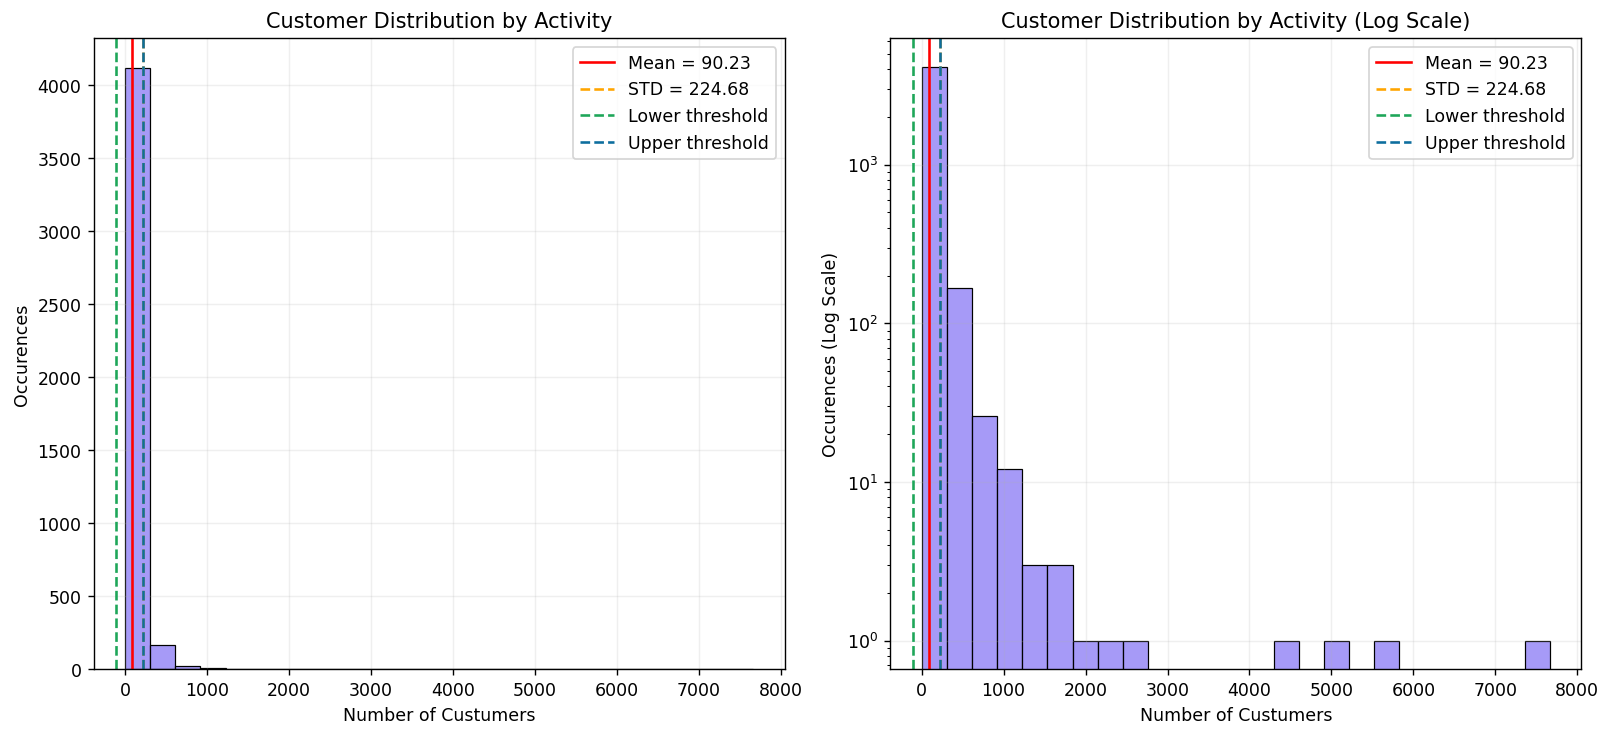

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (13, 6), dpi = 125)

#============ Plot 1 ==========
sns.histplot(custumer_counts, bins = 25, ax = ax1, color = '#8978f5', edgecolor = 'black', linewidth = 0.7)
ax1.axvline(customer_mean, color = 'red', label = f'Mean = {customer_mean:.2f}')
ax1.axvline(customer_std, color = 'orange', ls = '--', label = f'STD = {customer_std:.2f}')
ax1.axvline(customer_lower_threshold, color = '#1ea659', ls = '--', label = 'Lower threshold')
ax1.axvline(customer_upper_threshold, color = '#0d6e9e', ls = '--', label = 'Upper threshold')

ax1.set_title('Customer Distribution by Activity')
ax1.set_xlabel('Number of Custumers')
ax1.set_ylabel('Occurences')
ax1.legend()
ax1.grid(alpha = 0.2)

#============ Plot 2 ==========
sns.histplot(custumer_counts, bins = 25, ax = ax2, color = '#8978f5', edgecolor = 'black', linewidth = 0.7)
ax2.axvline(customer_mean, color = 'red', label = f'Mean = {customer_mean:.2f}')
ax2.axvline(customer_std, color = 'orange', ls = '--', label = f'STD = {customer_std:.2f}')
ax2.axvline(customer_lower_threshold, color = '#1ea659', ls = '--', label = 'Lower threshold')
ax2.axvline(customer_upper_threshold, color = '#0d6e9e', ls = '--', label = 'Upper threshold')

ax2.set_yscale('log')

ax2.set_title('Customer Distribution by Activity (Log Scale)')
ax2.set_xlabel('Number of Custumers')
ax2.set_ylabel('Occurences (Log Scale)')
ax2.legend()
ax2.grid(alpha = 0.2)


plt.tight_layout() # Prevents labels from overlapping
plt.show()

For futher steps. Analisys of Quantity column

$$IQR = Q3 - Q1 \rightarrow 10 - 1 = 9$$
$$Upper Fence = Q3 + 1.5 \times IQR \rightarrow 10 + 1.5 \times 9 = 23.5$$
$$Lover Fence = Q1 - 1.5 \times IQR \rightarrow 1 - 1.5 \times 9 = -12,5$$

When devided date/time column, answer for:
    - Seasonality: Which months have the highest sales?
    - Weekly Patterns: Do customers shop more on weekends?
    - Daily Cycles: What is the "peak hour" for orders?